# Calculative Foundation Project
This notebook covers vectors, matrices, transformations, eigenvalues, PCA, and LDA with intuition.

## Part A: Vector & Matrix Fundamentals

### 1. Represent student scores as vectors
**Intuition:** Each student is a vector where each value = subject score.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Example data (3 students, 3 subjects)
student1 = np.array([85, 78, 92])
student2 = np.array([88, 76, 95])
student3 = np.array([90, 82, 88])

student1, student2, student3

(array([85, 78, 92]), array([88, 76, 95]), array([90, 82, 88]))

### 2. Norms, Dot Product, Cross Product
**Intuition:** Norm = length, Dot = similarity, Cross = perpendicular direction

In [26]:
# Norms
norm1 = np.linalg.norm(student1, 1)
norm2 = np.linalg.norm(student1, 2)

# Dot product
dot_product = np.dot(student1, student2)

# Cross product (3D only)
cross_product = np.cross(student1, student2)

norm1, norm2, dot_product, cross_product

(np.float64(255.0),
 np.float64(147.5567687366459),
 np.int64(22148),
 array([ 418,   21, -404]))

### 3. Projection
**Intuition:** Projection shows how much one vector aligns with another

In [27]:
projection = (np.dot(student1, student2) / np.dot(student2, student2)) * student2
projection

array([86.45038811, 74.66169882, 93.32712353])

## Part B: Matrix Operations

### 4. Matrix creation & operations
**Intuition:** Matrix = dataset, rows = students, columns = subjects

In [28]:
matrix = np.array([student1, student2, student3])

# Addition
add = matrix + matrix

# Multiplication
mul = np.dot(matrix, matrix.T)

# Transpose
transpose = matrix.T

# Determinant (square submatrix)
det = np.linalg.det(matrix[:, :3])

add, mul, transpose, det

(array([[170, 156, 184],
        [176, 152, 190],
        [180, 164, 176]]),
 array([[21773, 22148, 22142],
        [22148, 22545, 22512],
        [22142, 22512, 22568]]),
 array([[85, 88, 90],
        [78, 76, 82],
        [92, 95, 88]]),
 np.float64(3789.999999999994))

## Part C: Linear Transformations

### 5. Linear transformations
**Intuition:** Transformations change shape/space but keep structure

In [29]:
# Scaling transformation
scale_matrix = np.array([[2, 0], [0, 2]])
points = np.array([[1, 2], [3, 4]])

transformed = np.dot(points, scale_matrix)
transformed

array([[2, 4],
       [6, 8]])

## Part D: Eigenvalues & Decomposition

### 6. Eigenvalues & Eigenvectors
**Intuition:** Shows main direction of data

In [30]:
cov_matrix = np.cov(matrix.T)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvalues, eigenvectors

(array([2.36738479e+01, 4.32615209e+00, 2.00996130e-15]),
 array([[ 0.32657869,  0.93825777, -0.11409958],
        [ 0.62564513, -0.1241088 ,  0.77017217],
        [-0.70845926,  0.32290767,  0.6275477 ]]))

### 7. LU Decomposition
**Intuition:** Break matrix into lower and upper parts

In [31]:
from scipy.linalg import lu

P, L, U = lu(matrix)
P, L, U

(array([[0., 0., 1.],
        [0., 1., 0.],
        [1., 0., 0.]]),
 array([[ 1.        ,  0.        ,  0.        ],
        [ 0.97777778,  1.        ,  0.        ],
        [ 0.94444444, -0.13297872,  1.        ]]),
 array([[90.        , 82.        , 88.        ],
        [ 0.        , -4.17777778,  8.95555556],
        [ 0.        ,  0.        , 10.07978723]]))

### 8. SVD
**Intuition:** Break matrix into 3 parts for compression

In [32]:
U, S, V = np.linalg.svd(matrix)
U, S, V

(array([[-0.57070457,  0.20043162,  0.79631869],
        [-0.58057025,  0.58731972, -0.56390933],
        [-0.58071893, -0.78414457, -0.21882142]]),
 array([258.52350491,   6.85764397,   2.13778606]),
 array([[-0.58743121, -0.52705942, -0.61411151],
        [-0.27009105, -0.5876493 ,  0.76270514],
        [-0.76287312,  0.61390282,  0.20284951]]))

## Part E: Dimensionality Reduction

### 9. PCA
**Intuition:** Reduce dimensions while keeping maximum information

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(matrix)

reduced

array([[ 1.52412635, -2.31164564],
       [ 3.92105834,  1.72006827],
       [-5.44518468,  0.59157737]])

### 10. LDA
**Intuition:** Separate data into classes

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Labels: 0 = Below Avg, 1 = Above Avg
labels = np.array([1, 1, 0])

lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(matrix, labels)

lda_result

array([[ 0.20951312],
       [-1.20470044],
       [ 0.99518732]])

In [35]:
# Creating a sample dataset: Students x Subjects
data = {
    'Math': [85, 40, 90, 50, 95],
    'Science': [88, 45, 92, 55, 98],
    'History': [70, 80, 65, 85, 60]
}
df = pd.DataFrame(data, index=['Student_1', 'Student_2', 'Student_3', 'Student_4', 'Student_5'])
matrix_A = df.values

print("Student Score Matrix:")
print(df)

Student Score Matrix:
           Math  Science  History
Student_1    85       88       70
Student_2    40       45       80
Student_3    90       92       65
Student_4    50       55       85
Student_5    95       98       60


Geometry and Hyperplanes (Visualization)
To understand dimensionality, we visualize the student scores in 3D space.

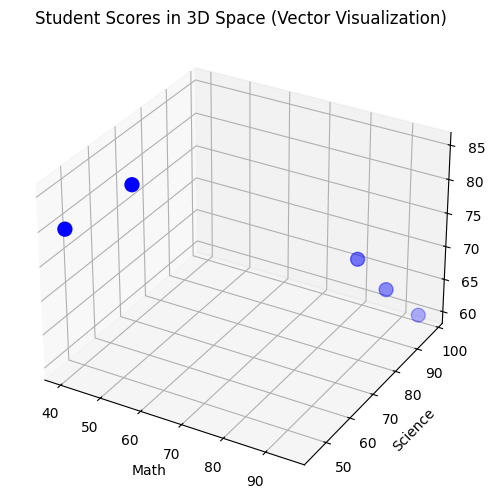

Intuition: Each student is a point in 3D. A plane would represent a linear relationship between two subjects.


In [36]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Math'], df['Science'], df['History'], c='blue', s=100)
ax.set_xlabel('Math')
ax.set_ylabel('Science')
ax.set_zlabel('History')
plt.title("Student Scores in 3D Space (Vector Visualization)")
plt.show()

print("Intuition: Each student is a point in 3D. A plane would represent a linear relationship between two subjects.")